In [1]:
import pandas as pd

data = {
    "age" : [16,17,16,18,17,16,18,17],
    "studytime" : [1,2,1,3,2,1,2,3],
    "failures" : [0,1,0,0,2,0,1,0],
    "absences" : [2, 4, 0, 10, 6, 1, 8, 2],
    "G1": [12, 10, 13, 14, 8, 15, 12, 14],
    "G2": [13, 11, 14, 15, 9, 16, 13, 15],
    "G3": [14, 12, 14, 15, 10, 17, 14, 16]
}
df=pd.DataFrame(data)
df



,age,studytime,failures,absences,G1,G2,G3
0,16,1,0,2,12,13,14
1,17,2,1,4,10,11,12
2,16,1,0,0,13,14,14
3,18,3,0,10,14,15,15
4,17,2,2,6,8,9,10
5,16,1,0,1,15,16,17
6,18,2,1,8,12,13,14
7,17,3,0,2,14,15,16


In [2]:
df.shape

(8, 7)

In [3]:
df.columns

Index(['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3'], dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        8 non-null      int64
 1   studytime  8 non-null      int64
 2   failures   8 non-null      int64
 3   absences   8 non-null      int64
 4   G1         8 non-null      int64
 5   G2         8 non-null      int64
 6   G3         8 non-null      int64
dtypes: int64(7)
memory usage: 580.0 bytes


In [5]:
df.describe()

,age,studytime,failures,absences,G1,G2,G3
count,8.000000,8.000000,8.000000,8.000000,8.00000,8.00000,8.000000
mean,16.875000,1.875000,0.500000,4.125000,12.25000,13.25000,14.000000
std,0.834523,0.834523,0.755929,3.563205,2.31455,2.31455,2.203893
min,16.000000,1.000000,0.000000,0.000000,8.00000,9.00000,10.000000
25%,16.000000,1.000000,0.000000,1.750000,11.50000,12.50000,13.500000
50%,17.000000,2.000000,0.000000,3.000000,12.50000,13.50000,14.000000
75%,17.250000,2.250000,1.000000,6.500000,14.00000,15.00000,15.250000
max,18.000000,3.000000,2.000000,10.000000,15.00000,16.00000,17.000000


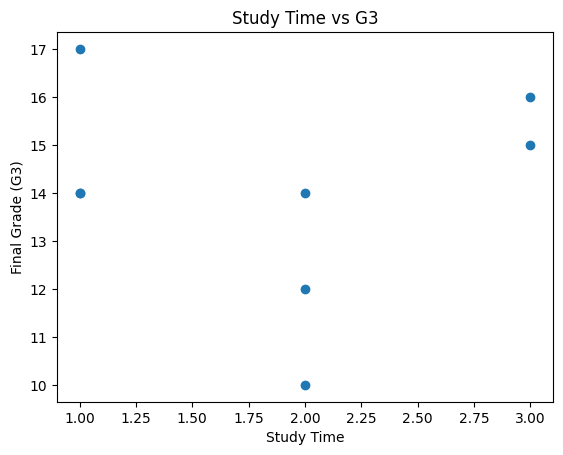

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs G3")
plt.show()


In [7]:
corr = df.corr()
corr

,age,studytime,failures,absences,G1,G2,G3
age,1.000000,7.948718e-01,0.339683,0.918807,-0.129430,-0.129430,-1.553471e-01
studytime,0.794872,1.000000e+00,0.113228,0.630554,0.018490,0.018490,-3.449399e-17
failures,0.339683,1.132277e-01,1.000000,0.397779,-0.898146,-0.898146,-8.574929e-01
absences,0.918807,6.305539e-01,0.397779,1.000000,-0.229515,-0.229515,-2.728739e-01
G1,-0.129430,1.849001e-02,-0.898146,-0.229515,1.000000,1.000000,9.801961e-01
G2,-0.129430,1.849001e-02,-0.898146,-0.229515,1.000000,1.000000,9.801961e-01
G3,-0.155347,-3.449399e-17,-0.857493,-0.272874,0.980196,0.980196,1.000000e+00


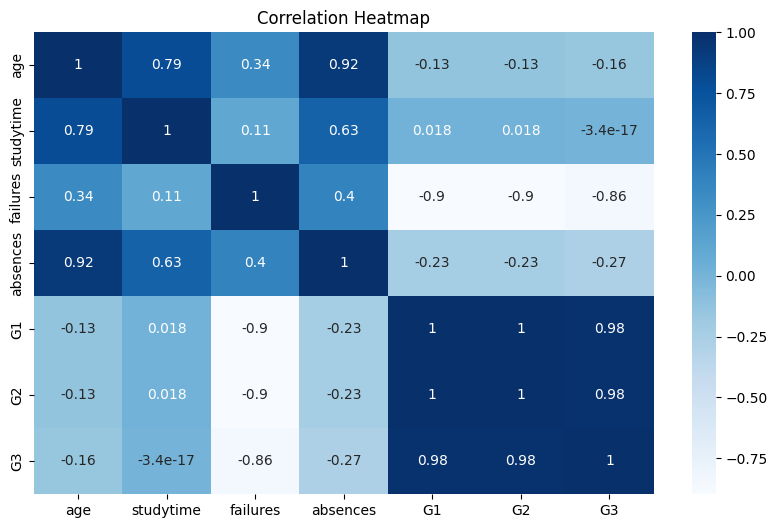

In [8]:
import seaborn as sns


plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

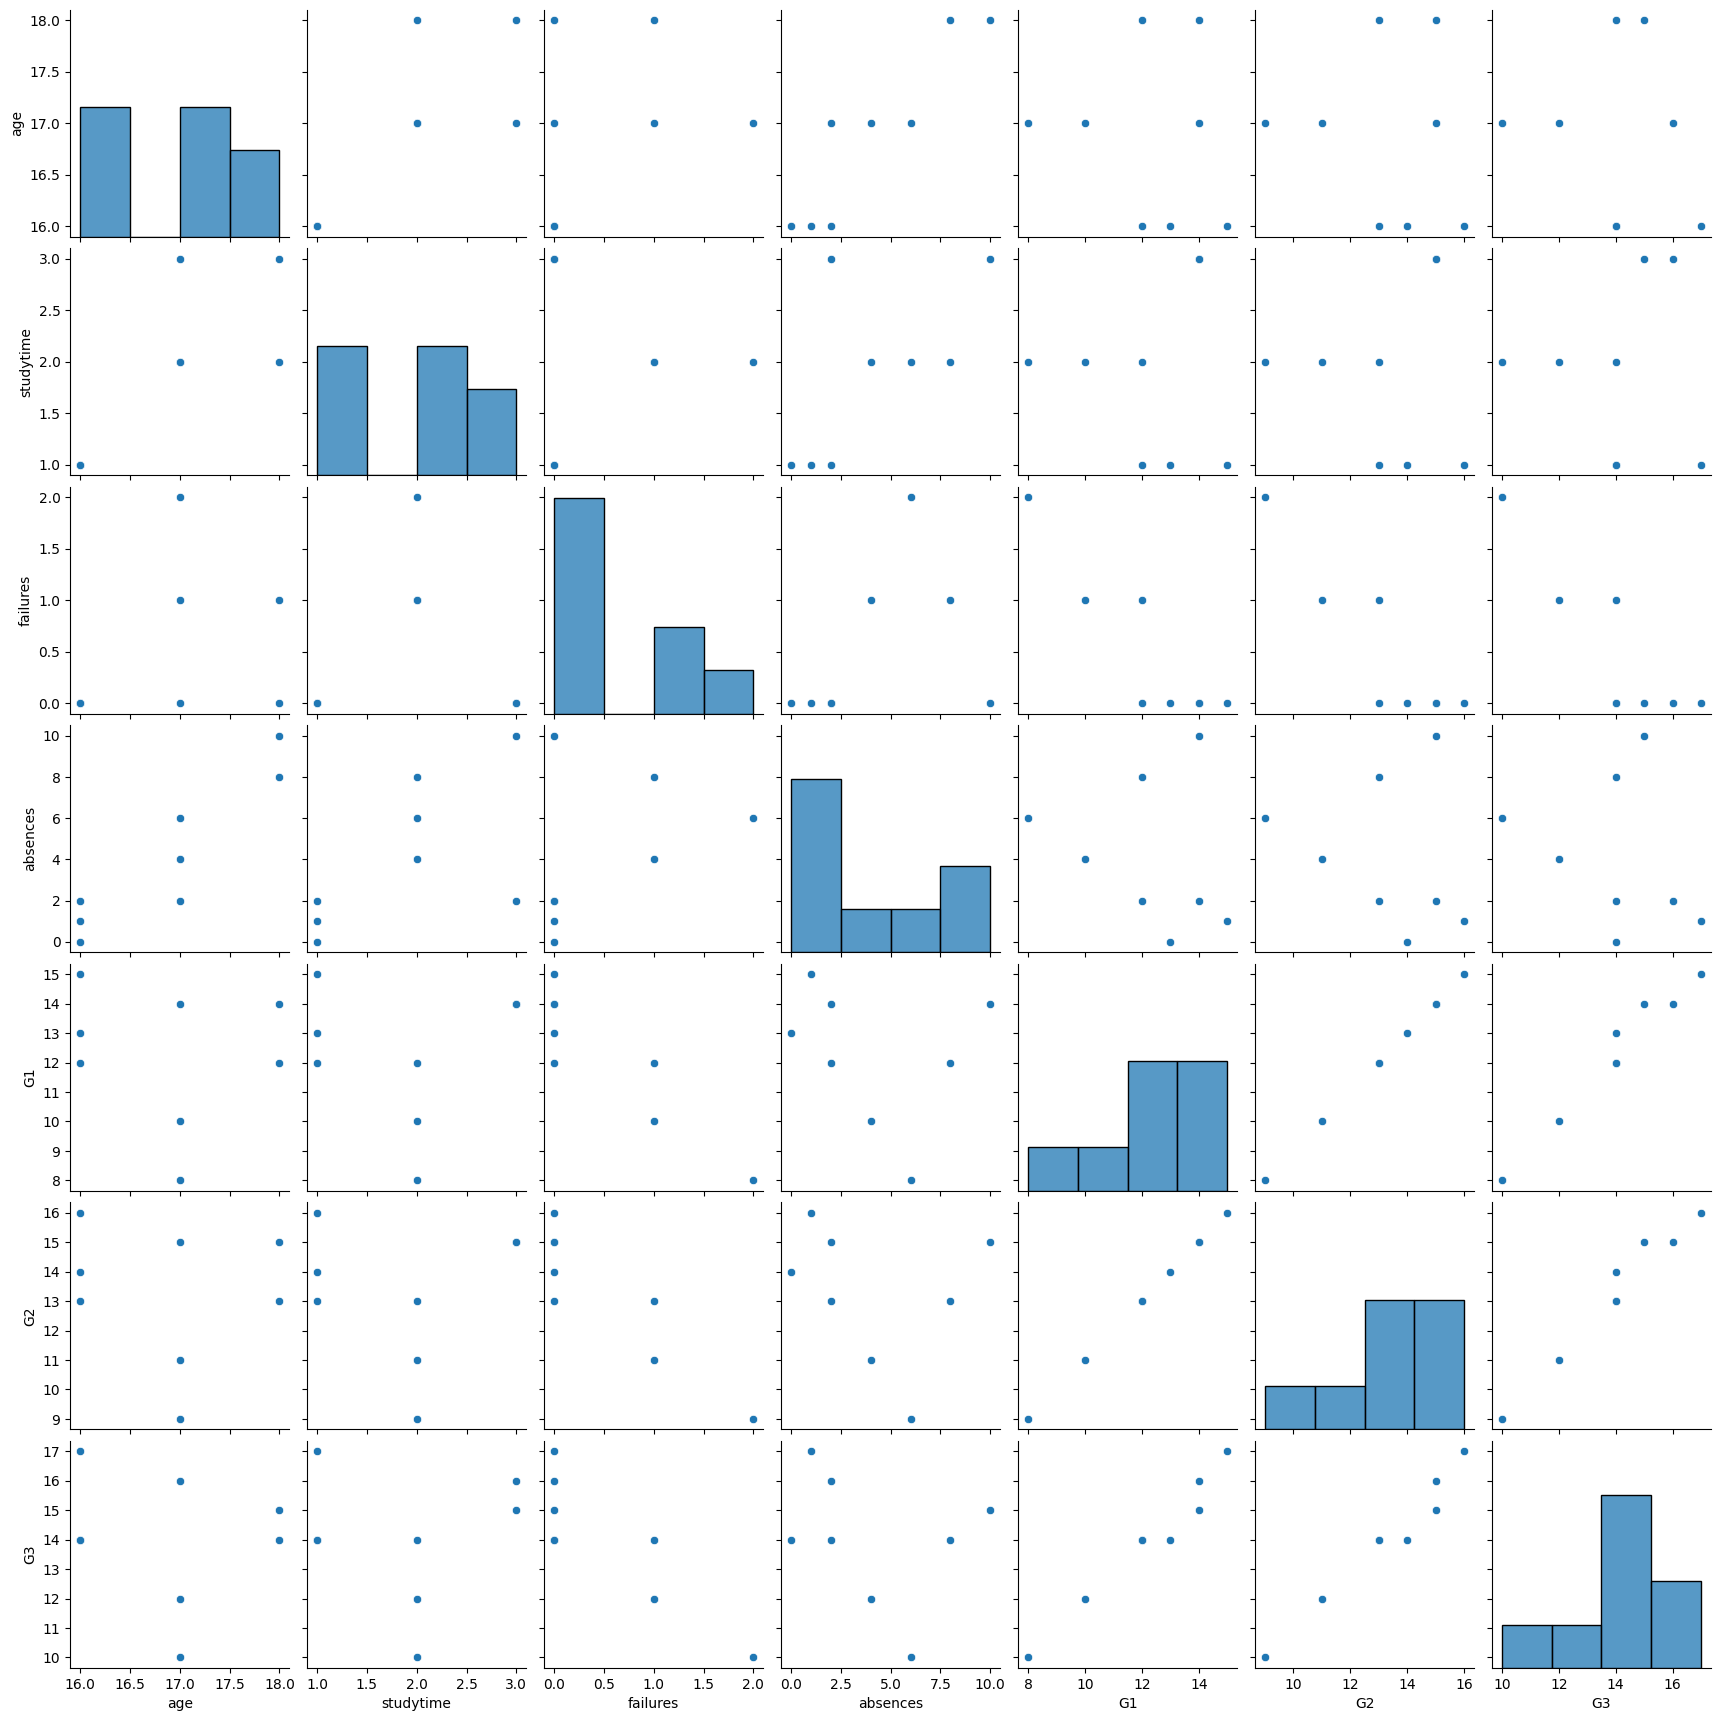

In [9]:
sns.pairplot(df)
plt.show()

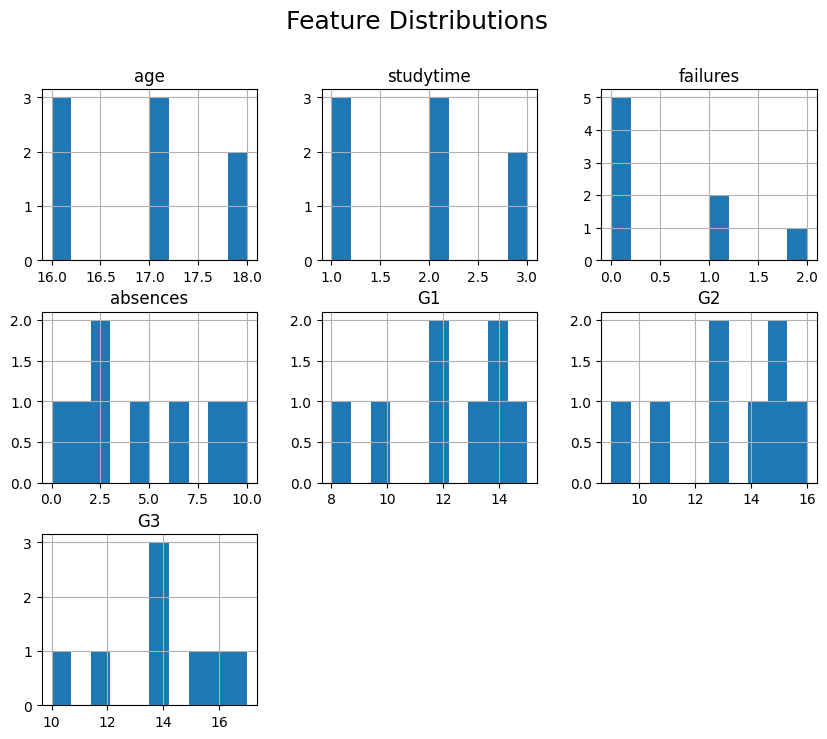

In [10]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions", fontsize=18 )
plt.show()

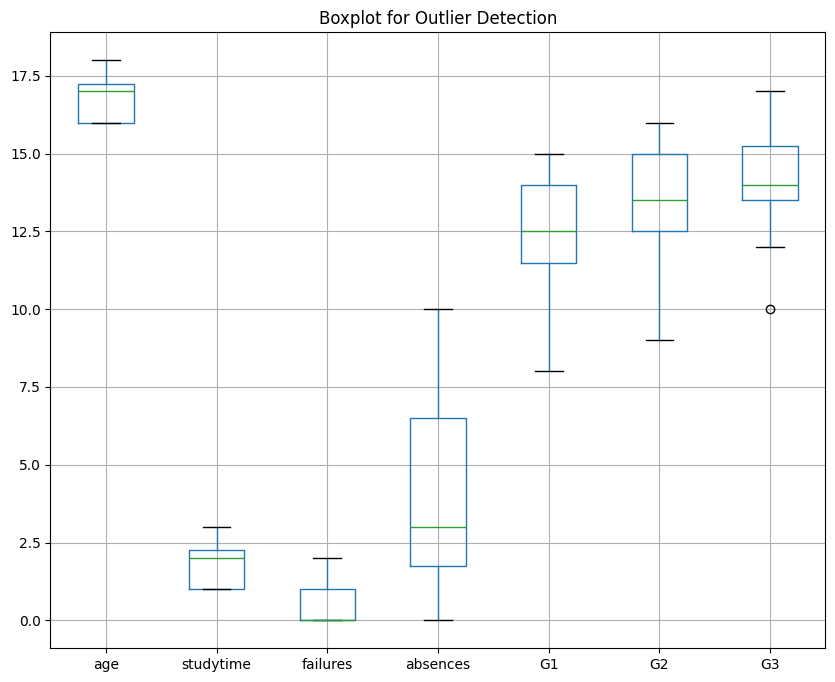

In [11]:
plt.figure(figsize=(10,8))
df.boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

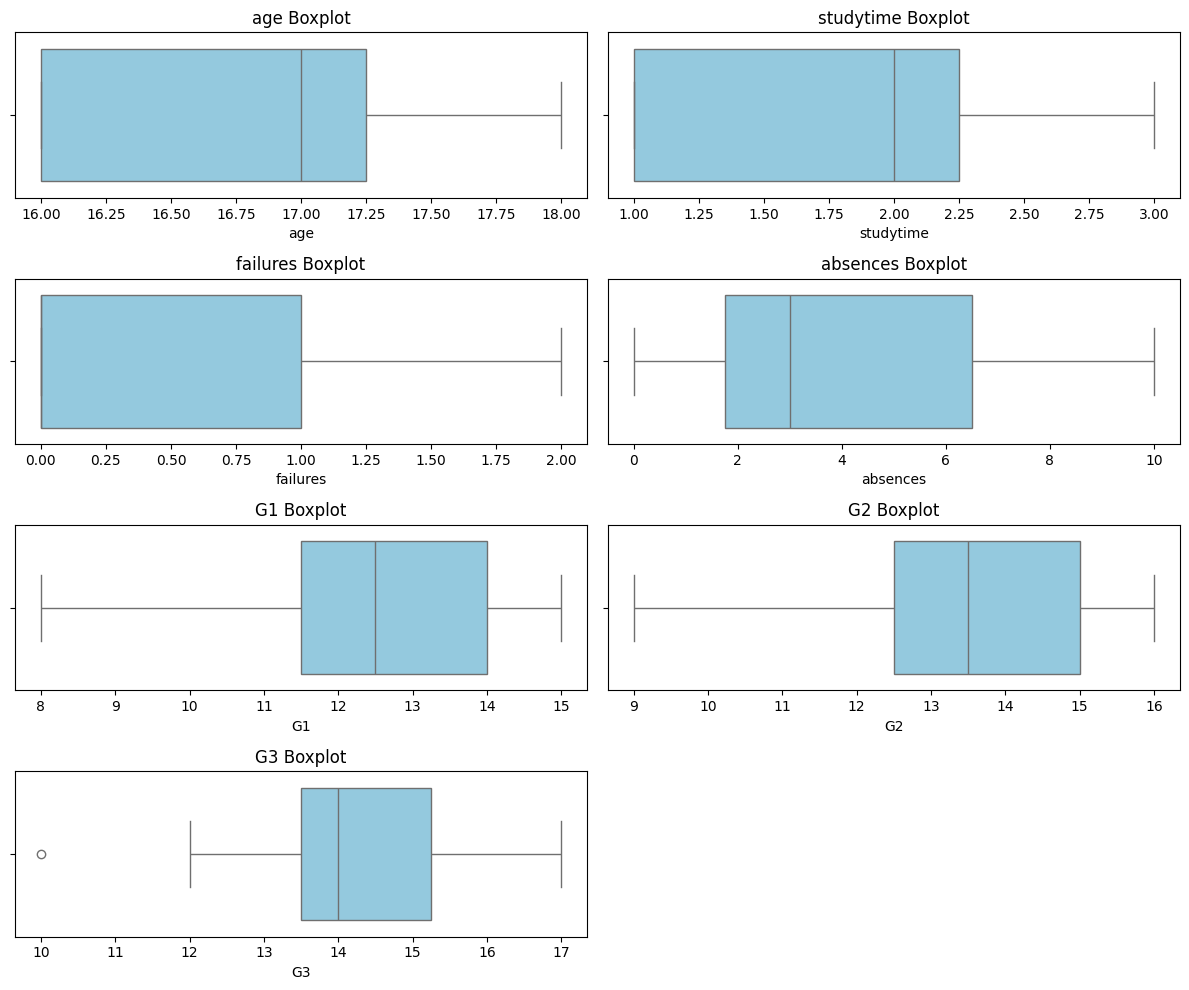

In [12]:
features = ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
plt.figure(figsize=(12,10))
for i, col in enumerate(features, 1):
  plt.subplot(4,2,i)
  sns.boxplot(x = df[col], color = "skyblue")
  plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()

In [13]:
X= df[["age", "studytime", "failures", "absences", "G1", "G2"]]
y = df["G3"]
X.head(), y.head()

(   age  studytime  failures  absences  G1  G2
 0   16          1         0         2  12  13
 1   17          2         1         4  10  11
 2   16          1         0         0  13  14
 3   18          3         0        10  14  15
 4   17          2         2         6   8   9,
 0    14
 1    12
 2    14
 3    15
 4    10
 Name: G3, dtype: int64)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train.shape, X_test.shape

((6, 6), (2, 6))

In [15]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
model.coef_, model.intercept_

(array([ 6.33333333, -0.33333333, -6.83333333, -0.91666667, -0.91666667,
        -0.91666667]),
 np.float64(-62.25000000000009))

In [17]:
y_pred=model.predict(X_test)
y_pred

array([15.        ,  9.41666667])

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)
mae, rmse, r2

(5.2916666666666785, np.float64(5.7665823693260725), -4.320555555555568)

In [19]:
coef = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : model.coef_
})
coef

,Feature,Coefficient
0,age,6.333333
1,studytime,-0.333333
2,failures,-6.833333
3,absences,-0.916667
4,G1,-0.916667
5,G2,-0.916667


In [20]:
residuals=y_test-y_pred
residuals
np.mean(residuals), np.std(residuals)

(np.float64(2.291666666666657), np.float64(5.2916666666666785))

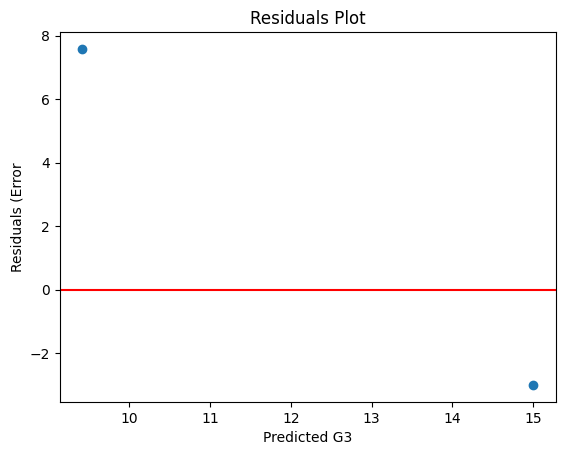

In [21]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color = "red")
plt.xlabel("Predicted G3")
plt.ylabel("Residuals (Error")
plt.title("Residuals Plot")
plt.show()

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
rf_pred=rf.predict(X_test)
rf_pred

array([12.62, 14.95])

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse =np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
rf_mae, rf_rmse, rf_r2

(1.335, np.float64(1.5144140781173427), 0.6330479999999998)

In [ ]:
fi=pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

fi.sort_values(by="Importance", ascending=False)

,Feature,Importance
4,G1,0.305100
5,G2,0.284176
2,failures,0.205474
1,studytime,0.108384
0,age,0.052928
3,absences,0.043937


In [33]:
comparison= pd.DataFrame ({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,5.291667,5.766582,-4.320556
1,Random Forest,1.335000,1.514414,0.633048


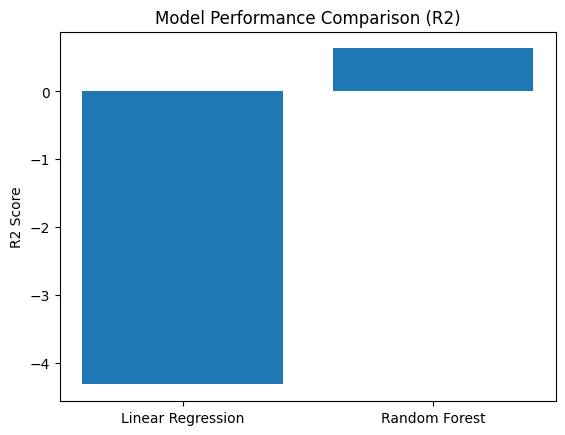

In [34]:
models = ["Linear Regression", "Random Forest"]
r2_scores = [r2, rf_r2]

plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison (R2)")
plt.show()